# DLinear Multivariate Forecasting — lon / lat / alt

This notebook trains a **DLinear** model (via [Darts](https://unit8co.github.io/darts/)) on the `italy_flights_20k` dataset.

- **Input (context):** 60 time-steps of `[lon, lat, alt]` (~10 min at 10 s spacing)
- **Output (forecast):** next 12 time-steps of `[lon, lat, alt]` (~2 min)
- Flights with fewer than 200 observations are dropped.
- Per-series `Scaler` is applied before training.
- Train / test split: 70 % / 30 % per flight.

In [ ]:
# Uncomment if darts is not yet installed:
# !pip install darts

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import DLinearModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mse, mae

## 1. Load data

In [32]:
df = pd.read_parquet("../data/italy_flights_20k.parquet")
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

print(f"Total rows: {len(df):,}")
print(f"Unique flights: {df['track_id'].nunique():,}")
df.head()

Total rows: 2,493,533
Unique flights: 13,919


,track_id,lon,lat,alt,timestamp,datetime
0,000001_2021-01-25,36.204828,31.774975,4732.02,1611588050,2021-01-25 15:20:50
1,000001_2021-01-25,36.215552,31.771251,4792.98,1611588060,2021-01-25 15:21:00
2,000001_2021-01-25,36.225934,31.767666,4853.94,1611588070,2021-01-25 15:21:10
3,000001_2021-01-25,36.236920,31.763942,4922.52,1611588080,2021-01-25 15:21:20
4,000001_2021-01-25,36.247128,31.760513,4998.72,1611588090,2021-01-25 15:21:30


## 2. Build per-flight TimeSeries objects

In [33]:
MIN_LENGTH = 200   # drop flights shorter than this
FREQ = "10s"       # 10-second sampling frequency

series_list = []
skipped = 0

for track_id, g in df.groupby("track_id"):
    g = g.sort_values("datetime").drop_duplicates(subset="datetime")

    if len(g) < MIN_LENGTH:
        skipped += 1
        continue

    try:
        ts = TimeSeries.from_dataframe(
            g,
            time_col="datetime",
            value_cols=["lon", "lat", "alt"],
            freq=FREQ,
            fill_missing_dates=True,
        )
        # Skip series with NaNs after freq enforcement
        if np.isnan(ts.values()).any():
            skipped += 1
            continue
        series_list.append(ts.astype(np.float32))
    except Exception as e:
        skipped += 1

print(f"Kept: {len(series_list)} flights  |  Skipped: {skipped}")

Kept: 4967 flights  |  Skipped: 8952


## 3. Scale & split

In [34]:
TRAIN_FRAC = 0.7

train_series_scaled = []
test_series_scaled  = []
scalers = []

for ts in series_list:
    train_raw, test_raw = ts.split_before(TRAIN_FRAC)

    scaler = Scaler()
    train_sc = scaler.fit_transform(train_raw)
    test_sc  = scaler.transform(test_raw)

    train_series_scaled.append(train_sc)
    test_series_scaled.append(test_sc)
    scalers.append(scaler)

print(f"Train series: {len(train_series_scaled)}  |  Test series: {len(test_series_scaled)}")

Train series: 4967  |  Test series: 4967


## 4. Define and train DLinear

In [52]:
INPUT_LEN  = 60   # context length (10-step increments = ~10 min)
OUTPUT_LEN = 12   # forecast horizon (~2 min)
N_EPOCHS   = 3

model = DLinearModel(
    input_chunk_length=INPUT_LEN,
    output_chunk_length=OUTPUT_LEN,
    n_epochs=N_EPOCHS,
    random_state=42,
    pl_trainer_kwargs={"enable_progress_bar": True},
)

model.fit(train_series_scaled, verbose=True)
print("Training complete.")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | decomposition   | _SeriesDecomp    | 0      | train
6 | linear_seasonal | Linear           | 6.5 K  | train
7 | linear_trend    | Linear           | 6.5 K  | train
-------------------------------------------------------------
13.0 K    Trainable params
0         Non-trainable params
13.0 K    Total params
0.052     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/da

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


Training complete.


## 5. Evaluate on test set

In [74]:
import random

SAMPLE_SIZE = 100  # number of flights to evaluate

indices = random.sample(range(len(test_series_scaled)), SAMPLE_SIZE)

mse_scores = []
mae_scores = []

for i in indices:
    train_sc = train_series_scaled[i]
    test_sc = test_series_scaled[i]

    context = train_sc[-INPUT_LEN:]

    forecast_sc = model.predict(n=OUTPUT_LEN, series=context)

    actual = test_sc[:OUTPUT_LEN]

    if len(actual) < OUTPUT_LEN:
        continue

    mse_scores.append(mse(actual, forecast_sc))
    mae_scores.append(mae(actual, forecast_sc))

print(f"Mean MSE across {len(mse_scores)} flights: {np.mean(mse_scores):.6f}")
print(f"Mean MAE across {len(mae_scores)} flights: {np.mean(mae_scores):.6f}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Mean MSE across 100 flights: 1.776498
Mean MAE across 100 flights: 0.124433


## 6. Visualise a sample forecast

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

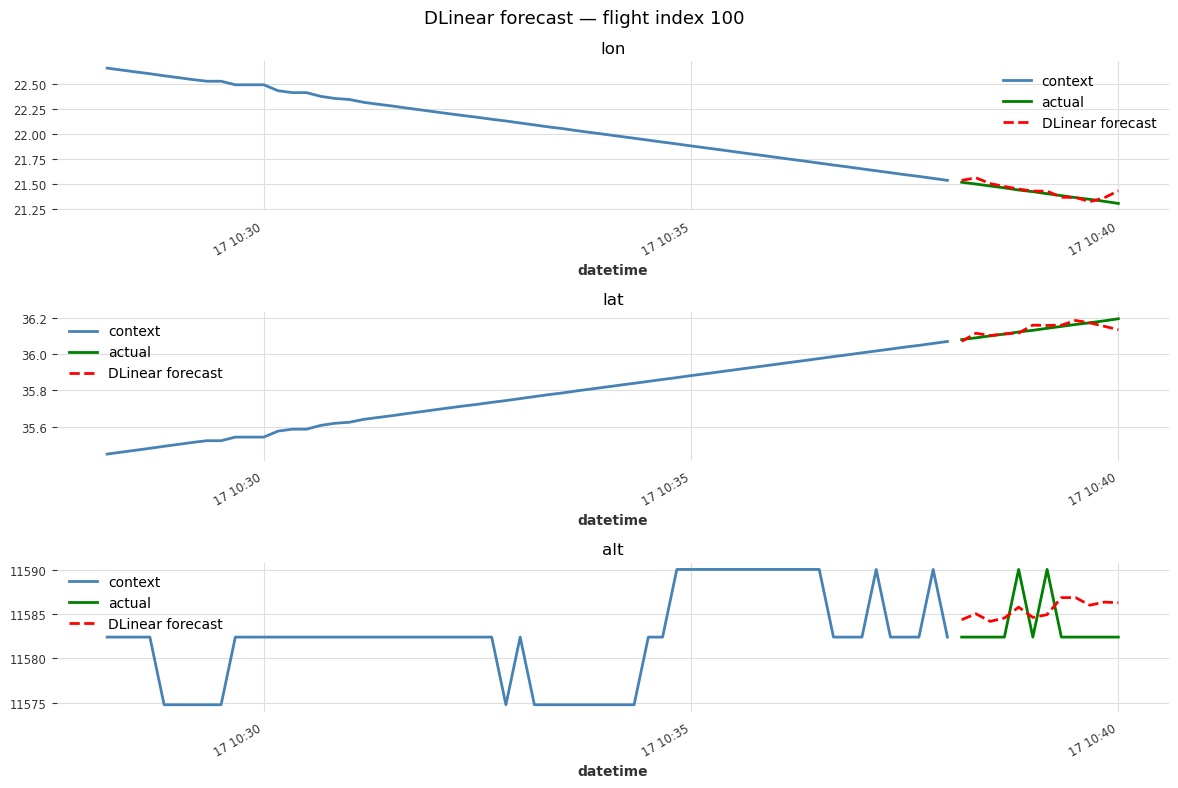

In [75]:
SAMPLE_IDX = 100  # change to inspect a different flight

train_sc = train_series_scaled[SAMPLE_IDX]
test_sc  = test_series_scaled[SAMPLE_IDX]
scaler   = scalers[SAMPLE_IDX]

context     = train_sc[-INPUT_LEN:]
forecast_sc = model.predict(n=OUTPUT_LEN, series=context)

# Inverse-transform back to original scale
actual_orig   = scaler.inverse_transform(test_sc[:OUTPUT_LEN])
forecast_orig = scaler.inverse_transform(forecast_sc)
context_orig  = scaler.inverse_transform(context)

feature_names = ["lon", "lat", "alt"]
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for i, (ax, feat) in enumerate(zip(axes, feature_names)):
    context_orig[feat].plot(ax=ax, label="context", color="steelblue")
    actual_orig[feat].plot(ax=ax, label="actual", color="green")
    forecast_orig[feat].plot(ax=ax, label="DLinear forecast", color="red", linestyle="--")
    ax.set_title(feat)
    ax.legend()

plt.suptitle(f"DLinear forecast — flight index {SAMPLE_IDX}", fontsize=13)
plt.tight_layout()
plt.show()

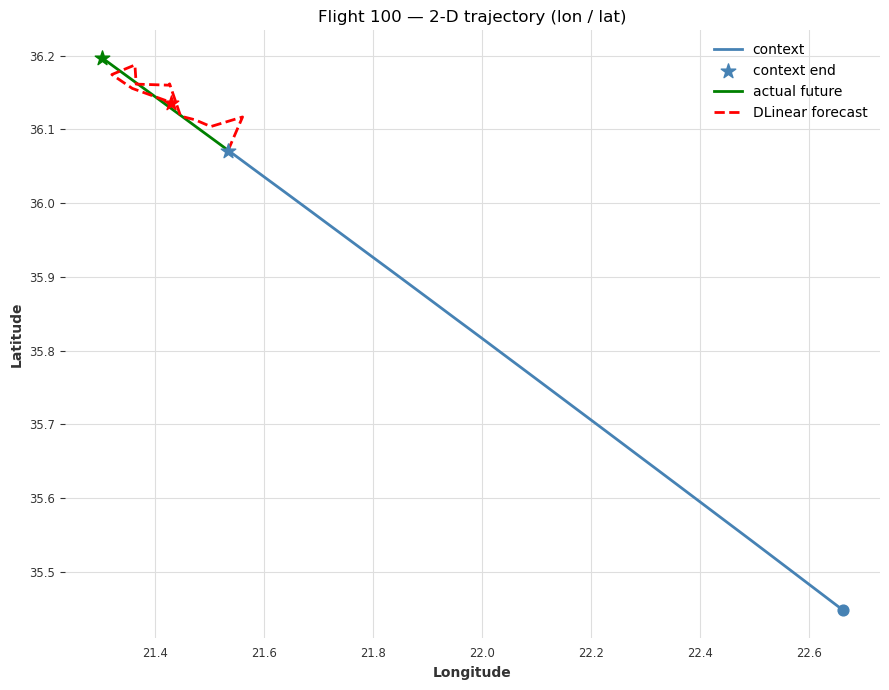

In [76]:
## 7. 2-D trajectory plot (lon vs lat)

# Extract numpy arrays — shape [T, 3], columns: lon, lat, alt
ctx_vals = context_orig.values()   # [INPUT_LEN, 3]
act_vals = actual_orig.values()    # [OUTPUT_LEN, 3]
fct_vals = forecast_orig.values()  # [OUTPUT_LEN, 3]

fig, ax = plt.subplots(figsize=(9, 7))

# Context path
ax.plot(ctx_vals[:, 0], ctx_vals[:, 1],
        color='steelblue', linewidth=2, label='context')
ax.scatter(ctx_vals[0, 0],  ctx_vals[0, 1],  color='steelblue', s=60, zorder=5)
ax.scatter(ctx_vals[-1, 0], ctx_vals[-1, 1], color='steelblue', s=120,
           marker='*', zorder=5, label='context end')

# Actual (ground-truth) future — connected from last context point
ax.plot(
    [ctx_vals[-1, 0]] + list(act_vals[:, 0]),
    [ctx_vals[-1, 1]] + list(act_vals[:, 1]),
    color='green', linewidth=2, label='actual future'
)
ax.scatter(act_vals[-1, 0], act_vals[-1, 1], color='green', s=120,
           marker='*', zorder=5)

# Forecast — connected from last context point
ax.plot(
    [ctx_vals[-1, 0]] + list(fct_vals[:, 0]),
    [ctx_vals[-1, 1]] + list(fct_vals[:, 1]),
    color='red', linewidth=2, linestyle='--', label='DLinear forecast'
)
ax.scatter(fct_vals[-1, 0], fct_vals[-1, 1], color='red', s=120,
           marker='*', zorder=5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Flight {SAMPLE_IDX} — 2-D trajectory (lon / lat)')
ax.legend()
plt.tight_layout()
plt.show()

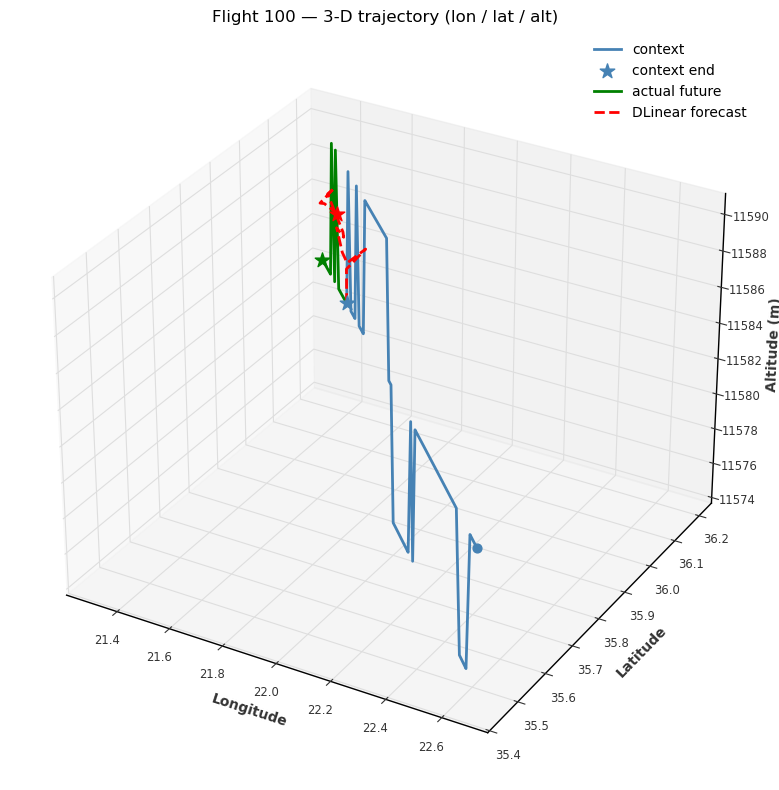

In [77]:
## 8. 3-D trajectory plot (lon, lat, alt)

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3-D projection

fig = plt.figure(figsize=(11, 8))
ax3 = fig.add_subplot(111, projection='3d')

# Context path
ax3.plot(ctx_vals[:, 0], ctx_vals[:, 1], ctx_vals[:, 2],
         color='steelblue', linewidth=2, label='context')
ax3.scatter(*ctx_vals[0],  color='steelblue', s=40, zorder=5)
ax3.scatter(*ctx_vals[-1], color='steelblue', s=120,
            marker='*', zorder=5, label='context end')

# Actual future — connect from last context point
bridge_act_lon = [ctx_vals[-1, 0]] + list(act_vals[:, 0])
bridge_act_lat = [ctx_vals[-1, 1]] + list(act_vals[:, 1])
bridge_act_alt = [ctx_vals[-1, 2]] + list(act_vals[:, 2])
ax3.plot(bridge_act_lon, bridge_act_lat, bridge_act_alt,
         color='green', linewidth=2, label='actual future')
ax3.scatter(*act_vals[-1], color='green', s=120, marker='*', zorder=5)

# Forecast — connect from last context point
bridge_fct_lon = [ctx_vals[-1, 0]] + list(fct_vals[:, 0])
bridge_fct_lat = [ctx_vals[-1, 1]] + list(fct_vals[:, 1])
bridge_fct_alt = [ctx_vals[-1, 2]] + list(fct_vals[:, 2])
ax3.plot(bridge_fct_lon, bridge_fct_lat, bridge_fct_alt,
         color='red', linewidth=2, linestyle='--', label='DLinear forecast')
ax3.scatter(*fct_vals[-1], color='red', s=120, marker='*', zorder=5)

ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.set_zlabel('Altitude (m)')
ax3.set_title(f'Flight {SAMPLE_IDX} — 3-D trajectory (lon / lat / alt)')
ax3.legend()
plt.tight_layout()
plt.show()

## 9. Save model weights

In [78]:
import os
os.makedirs('saved_models', exist_ok=True)
save_path = os.path.join('saved_models', 'dlinear')
model.save(save_path)
print(f'Model saved to {save_path}')

Model saved to saved_models/dlinear
